Dataset Preview:
   Feature1  Feature2
0 -7.430860 -7.899923
1 -7.912123 -7.341576
2 -1.522144  7.549274
3  4.378661  3.291702
4 -9.325377 -8.089813


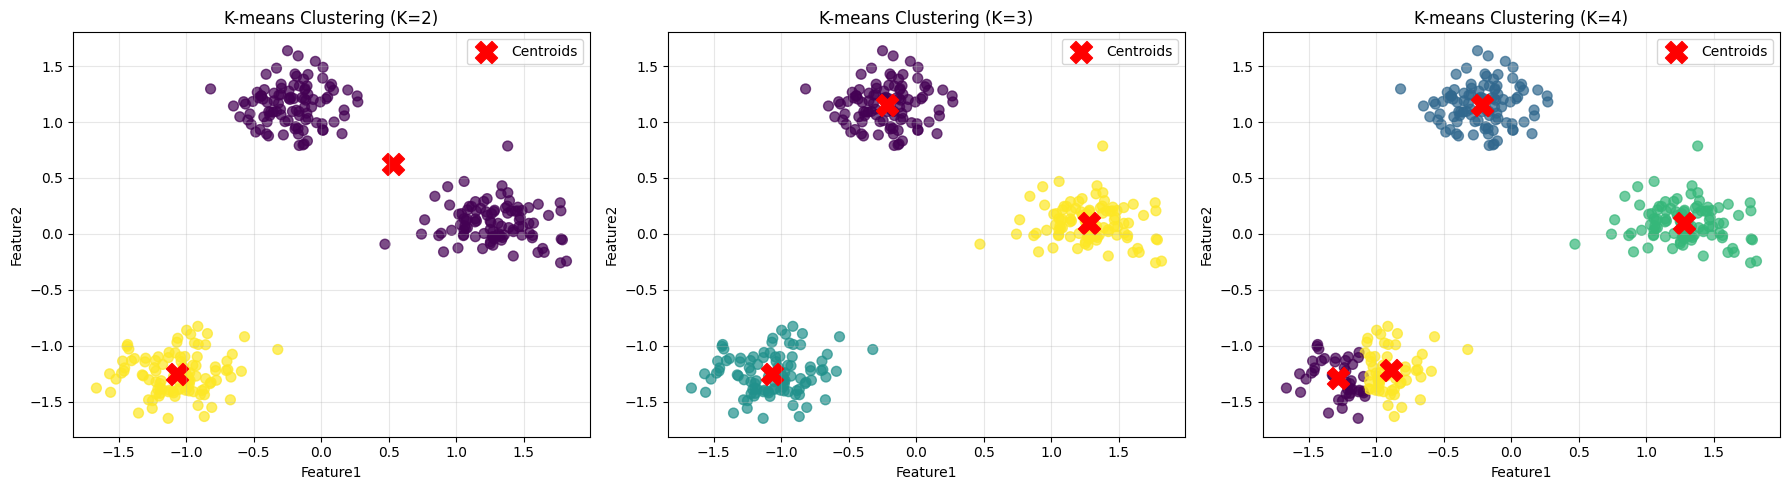

In [1]:
# Objective: Understand basic clustering with K-means
# Tasks:
# - Apply K-means with K = 2, 3, 4
# - Plot clusters and centroids

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
# Replace with your file name if different
data = pd.read_csv("kmeans_basic.csv")

# Preview data
print("Dataset Preview:")
print(data.head())

# Use first two numeric columns for visualization
X = data.select_dtypes(include=['number']).iloc[:, :2]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

k_values = [2, 3, 4]

for i, k in enumerate(k_values):
    # Fit K-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    centroids = kmeans.cluster_centers_

    # Plot clusters
    ax = axes[i]
    scatter = ax.scatter(
        X_scaled[:, 0], X_scaled[:, 1],
        c=labels, cmap='viridis', s=50, alpha=0.7
    )

    # Plot centroids
    ax.scatter(
        centroids[:, 0], centroids[:, 1],
        marker='X', s=250, c='red', label='Centroids'
    )

    ax.set_title(f"K-means Clustering (K={k})")
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
1.	How does cluster structure change as K increases? 
K = 2
Data is divided into 2 broad groups
Large regions may contain multiple natural subgroups
Simpler but may under-cluster
K = 3
Clusters become more refined
Previously merged groups may separate
Often closer to natural structure (if true clusters ≈ 3)
K = 4
Data is split into smaller groups
Existing clusters may be divided further
Can capture finer patterns, but may over-cluster
General behavior
More centroids appear
Cluster sizes often become smaller
Within-cluster distances decrease
Boundaries become more granular
Risk of splitting meaningful groups increases
2.	Which K gives the most meaningful grouping? Why? 
The best K is the one that gives compact, well-separated, interpretable clusters — often K = 3 in this kind of exercise, but the plot is the final judge.
3.	What do centroids represent in this dataset? 
For every cluster, K-means computes the mean of all points assigned to that cluster:

Centroid=average of feature values of points in that cluster


Dataset Preview:
    Feature1   Feature2
0 -12.039401  11.710508
1  -9.058560  11.069042
2  -9.452685   6.641714
3   7.077678   1.605526
4   6.067105   4.812084

K vs Inertia:
K = 1: 800.0000
K = 2: 465.0143
K = 3: 176.4808
K = 4: 110.7553
K = 5: 98.5127
K = 6: 87.5805
K = 7: 77.7143
K = 8: 66.9738
K = 9: 59.6154
K = 10: 52.6215


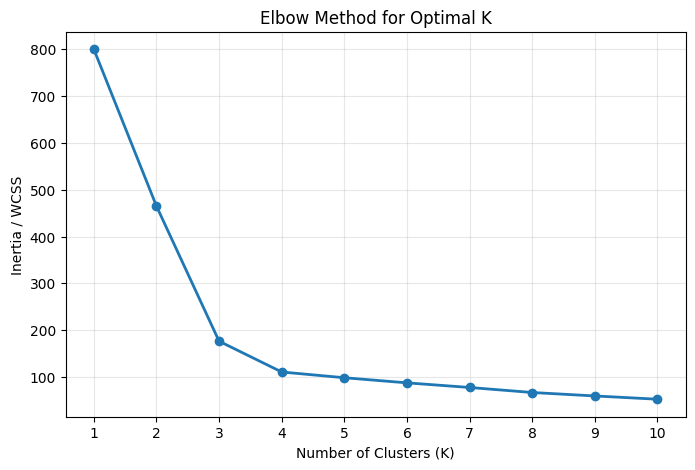

In [1]:
# Objective: Understand and Find Optimal K using Elbow Method
# Tasks:
# 1. Run K-means for K = 1 to 10
# 2. Plot K vs Inertia (WCSS)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("kmeans_elbow.csv")

# Preview data
print("Dataset Preview:")
print(data.head())

# Use numeric columns only
X = data.select_dtypes(include=['number'])

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute inertia for K = 1 to 10
k_values = range(1, 11)
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Print values
print("\nK vs Inertia:")
for k, val in zip(k_values, inertia_values):
    print(f"K = {k}: {val:.4f}")

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_values, marker='o', linewidth=2)
plt.xticks(k_values)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method for Optimal K")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
1.	Identify the “elbow point” in the graph 
At K = 3, adding more clusters still reduces inertia, but with diminishing returns.

Optimal K (Elbow Point) = 3
2.	Why does inertia always decrease as K increases? 
Inertia decreases with larger K because more clusters let centroids fit the data more closely

3.	Is the elbow point clearly visible? What does that imply? 
The elbow is reasonably clear at K = 3, suggesting the dataset likely has 3 natural clusters.
    Natural cluster structure likely exists
Good trade-off at K = 3
Reasonable model simplicity

Dataset Preview:
   Feature1   Feature2
0 -7.112997  -6.782198
1 -4.353466  -8.579587
2  7.833021 -12.434260
3 -8.412982  -5.201894
4  9.360637 -10.596066
Random State 0: Inertia = 177.9918
Random State 1: Inertia = 177.9918
Random State 2: Inertia = 178.0952
Random State 42: Inertia = 178.0952
Random State 100: Inertia = 178.0952

Pairwise Similarity of Cluster Assignments (ARI):
0 vs 1: ARI = 1.0000
0 vs 2: ARI = 0.9442
0 vs 42: ARI = 0.9442
0 vs 100: ARI = 0.9442
1 vs 2: ARI = 0.9442
1 vs 42: ARI = 0.9442
1 vs 100: ARI = 0.9442
2 vs 42: ARI = 1.0000
2 vs 100: ARI = 1.0000
42 vs 100: ARI = 1.0000


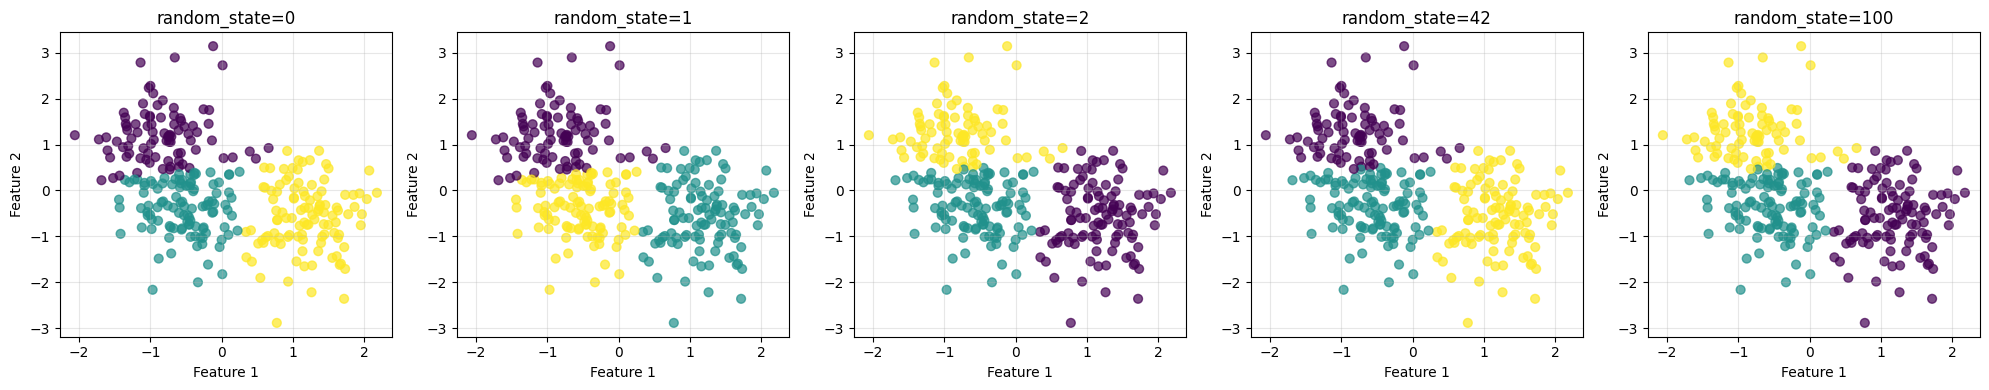

In [1]:
# Objective: Study Initialization Effect in K-means
# Tasks:
# 1. Run K-means multiple times with different random states
# 2. Keep K fixed at 3
# 3. Compare cluster assignments

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Load dataset
data = pd.read_csv("kmeans_init.csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# Use numeric columns
X = data.select_dtypes(include=['number'])

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fixed K
K = 3

# Different random states
random_states = [0, 1, 2, 42, 100]
results = {}

# Run K-means for each random state
for rs in random_states:
    kmeans = KMeans(n_clusters=K, random_state=rs, n_init=1)
    labels = kmeans.fit_predict(X_scaled)
    results[rs] = labels
    print(f"Random State {rs}: Inertia = {kmeans.inertia_:.4f}")

# Compare assignments using Adjusted Rand Index
print("\nPairwise Similarity of Cluster Assignments (ARI):")
for i in range(len(random_states)):
    for j in range(i+1, len(random_states)):
        rs1, rs2 = random_states[i], random_states[j]
        score = adjusted_rand_score(results[rs1], results[rs2])
        print(f"{rs1} vs {rs2}: ARI = {score:.4f}")

# Visualize first two features for each run
fig, axes = plt.subplots(1, len(random_states), figsize=(20, 4))

for idx, rs in enumerate(random_states):
    ax = axes[idx]
    ax.scatter(
        X_scaled[:, 0], X_scaled[:, 1],
        c=results[rs], cmap='viridis', s=40, alpha=0.7
    )
    ax.set_title(f"random_state={rs}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
1.	Do cluster results change across runs? 
Yes, results changed slightly across runs.
The clustering is mostly robust, but random initialization has a minor effect.
2.	Why is K-means sensitive to initialization? 
K-means is sensitive to initialization because it starts with initial centroids, and the algorithm then improves clusters from those starting points using a greedy local optimization process.

K-means is sensitive to initialization because random starting centroids can lead the algorithm to different local optima.    
3.	How can this issue be minimized? 
Use k-means++ + multiple initializations (n_init) + scaling to greatly reduce initialization sensitivity

Dataset Preview:
   Feature1   Feature2
0  0.496714 -82.899501
1 -0.138264 -56.018104
2  0.647689  74.729361
3  1.523030  61.037027
4 -0.234153  -2.090159

Inertia without scaling: 523247.3428
Inertia with scaling: 272.9958
Adjusted Rand Score between results: 0.241


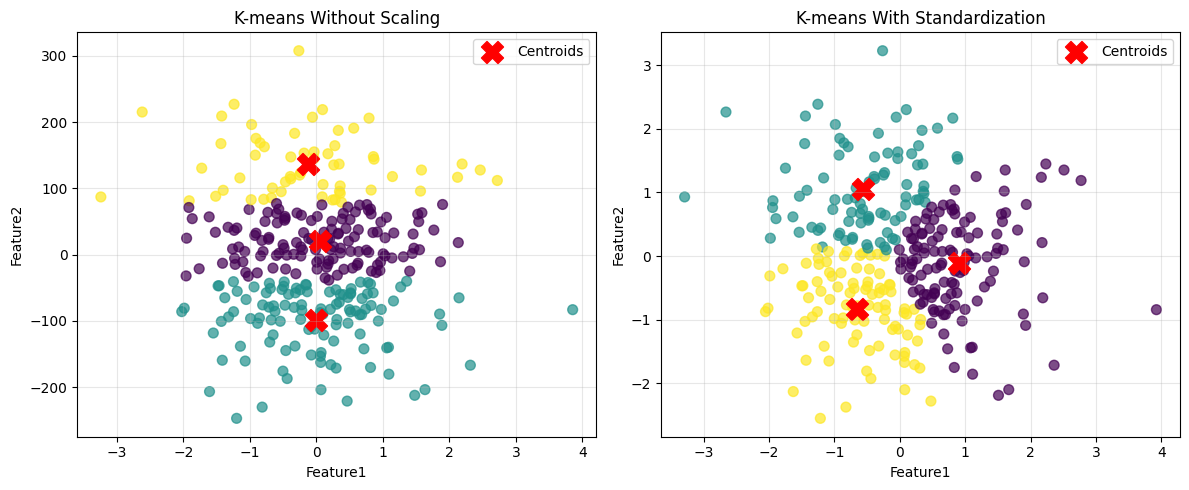

In [2]:
# Objective: Understand Scaling Impact in K-means
# Tasks:
# 1. Apply K-means without scaling
# 2. Apply K-means with standardization
# 3. Compare clustering results

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Load dataset
data = pd.read_csv("kmeans_scaling.csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# Use numeric columns
X = data.select_dtypes(include=['number'])

# -------------------------------
# K-means WITHOUT scaling
# -------------------------------
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(X)

# -------------------------------
# K-means WITH scaling
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

# -------------------------------
# Compare Results
# -------------------------------
print("\nInertia without scaling:", round(kmeans_raw.inertia_, 4))
print("Inertia with scaling:", round(kmeans_scaled.inertia_, 4))

ari = adjusted_rand_score(labels_raw, labels_scaled)
print("Adjusted Rand Score between results:", round(ari, 4))

# -------------------------------
# Visualization
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Without scaling
axes[0].scatter(
    X.iloc[:,0], X.iloc[:,1],
    c=labels_raw, cmap='viridis', s=50, alpha=0.7
)
axes[0].scatter(
    kmeans_raw.cluster_centers_[:,0],
    kmeans_raw.cluster_centers_[:,1],
    marker='X', s=250, c='red', label='Centroids'
)
axes[0].set_title("K-means Without Scaling")
axes[0].set_xlabel(X.columns[0])
axes[0].set_ylabel(X.columns[1])
axes[0].legend()
axes[0].grid(alpha=0.3)

# With scaling
axes[1].scatter(
    X_scaled[:,0], X_scaled[:,1],
    c=labels_scaled, cmap='viridis', s=50, alpha=0.7
)
axes[1].scatter(
    kmeans_scaled.cluster_centers_[:,0],
    kmeans_scaled.cluster_centers_[:,1],
    marker='X', s=250, c='red', label='Centroids'
)
axes[1].set_title("K-means With Standardization")
axes[1].set_xlabel(X.columns[0])
axes[1].set_ylabel(X.columns[1])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
1.	How do cluster assignments differ before and after scaling? 
Cluster assignments differ a lot before and after scaling.
Without scaling, clustering is dominated by Feature2; after scaling, both features influence the result fairly.
    2.	Which feature dominates before scaling? Why? 
Feature2 dominates before scaling because it has a much larger range/variance, so it contributes far more to Euclidean distance.
    3.	Why is scaling important for distance-based algorithms
Scaling is important because distance-based algorithms are sensitive to units and ranges; without scaling, results can be misleading.

Dataset Preview:
   Feature1  Feature2
0  0.682988 -0.345203
1  2.040990 -0.131615
2 -0.139752  0.454391
3  0.885748  0.286342
4  1.182459 -0.497711


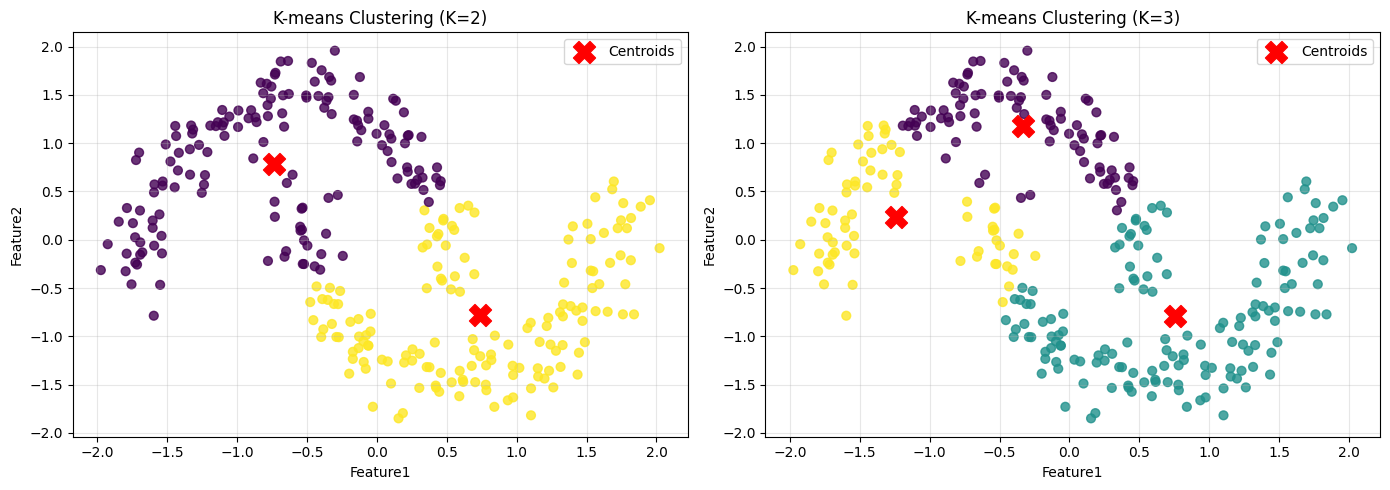

K = 2, Inertia = 252.6826
K = 3, Inertia = 188.9148


In [3]:
# Objective: Understand and Identify K-means Limitation
# Tasks:
# 1. Apply K-means (K = 2 or 3)
# 2. Plot clusters
# 3. Use plots to answer the questions

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("kmeans_nonlinear.csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# Use numeric columns
X = data.select_dtypes(include=['number'])

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try K = 2 and K = 3
k_values = [2, 3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    centers = kmeans.cluster_centers_

    ax = axes[i]
    ax.scatter(
        X_scaled[:, 0], X_scaled[:, 1],
        c=labels, cmap='viridis', s=40, alpha=0.8
    )
    ax.scatter(
        centers[:, 0], centers[:, 1],
        marker='X', s=250, c='red', label='Centroids'
    )

    ax.set_title(f"K-means Clustering (K={k})")
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print inertia values
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    print(f"K = {k}, Inertia = {model.inertia_:.4f}")

In [ ]:
1.	Does K-means correctly identify the natural clusters? 
No, K-means usually does not correctly identify the natural clusters in this nonlinear dataset.
2.	What is unusual about the shape of the data? 
The data has curved / non-spherical cluster shapes, not simple round clusters.
3.	What assumption of K-means is violated here? 
The violated assumption is that clusters are roughly spherical (round), compact, and separable by distance to a centroid.
The spherical / centroid-based cluster shape assumption of K-means is violated

Dataset Preview:
         F1        F2        F3        F4        F5        F6
0 -7.840318  4.427268  4.110675  4.021862 -8.480127  8.358291
1  7.866011 -4.231902 -5.365190 -6.763530 -3.511425  0.470933
2  6.461709 -4.767488 -5.176115 -3.742346 -3.335522  0.820925
3 -1.006841  9.088381  6.268494  0.593068 -8.583010 -6.935657
4 -0.050791 -2.779733  1.674890 -7.419345 -5.840545 -3.478633

PCA Explained Variance Ratio:
[0.67795598 0.21296832]


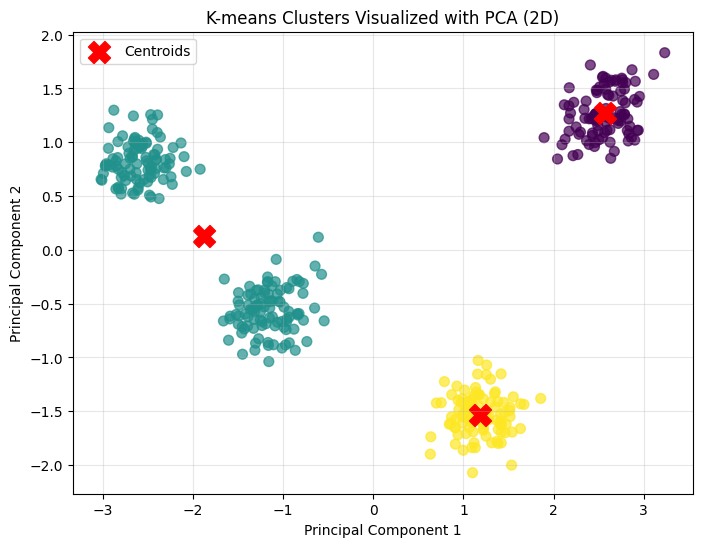

In [4]:
# Objective: Understand and work with high-dimensional data
# Tasks:
# 1. Apply K-means
# 2. Use PCA to reduce to 2D
# 3. Visualize clusters

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
data = pd.read_csv("kmeans_highdim.csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# Use numeric columns
X = data.select_dtypes(include=['number'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means
k = 3   # change if needed
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Print explained variance
print("\nPCA Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Plot clusters in 2D PCA space
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels, cmap='viridis', s=50, alpha=0.7
)

# Plot centroids
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=250, c='red', label='Centroids'
)

plt.title("K-means Clusters Visualized with PCA (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
1.	Why is PCA needed for visualization? 
    PCA kept about 89% of the variance in 2 components, so the 2D plot is informative.
    PCA is needed because high-dimensional data cannot be directly visualized, and PCA creates a meaningful 2D view while preserving most structure.
2.	Are clusters clearly visible after projection? 
Yes reasonably clear, because the first two PCA components capture about 89.1% of the total variance.
Clusters are likely clearly visible or at least reasonably well separated after projection
3.	Does dimensionality reduction affect interpretation? 
Yes,dimensionality reduction can affect interpretation, both positively and negatively.
es, dimensionality reduction affects interpretation: it improves visibility but may lose or distort some information.

Dataset Preview:
         Age  SpendingScore
0  27.483571      28.617357
1  28.238443      45.230299
2  23.829233      27.658630
3  32.896064      37.674347
4  22.652628      35.425600


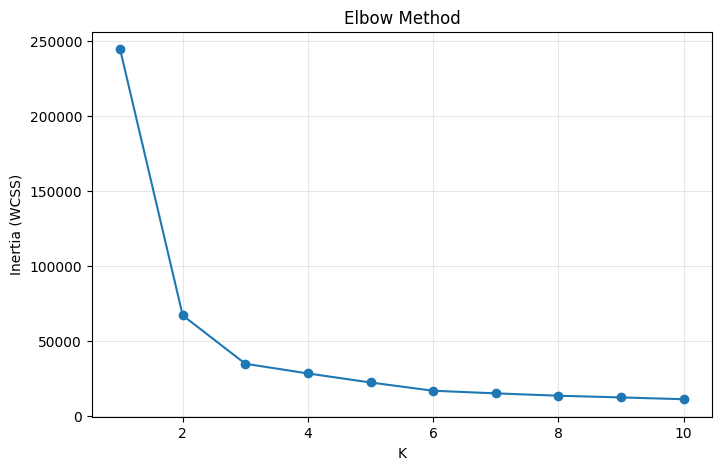


Cluster Mean Values:
               Age  SpendingScore
Cluster                          
0        45.641244      80.434876
1        49.774813      28.737273
2        24.422179      30.340223

Cluster Sizes:
Cluster
0    100
1    100
2    100
Name: count, dtype: int64

Saved cluster means as cluster_means.csv


In [5]:
# Objective: Understand and Interpret Clusters
# Tasks:
# 1. Apply K-means (choose appropriate K)
# 2. Compute mean values of each cluster
# 3. Analyze cluster characteristics

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("kmeans_interpret.csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# Use numeric columns
X = data.select_dtypes(include=['number'])

# -----------------------------
# Choose K using Elbow Method
# -----------------------------
inertia = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Apply K-means with chosen K
# (change K after viewing elbow, default=3)
# -----------------------------
k = 3

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels
data["Cluster"] = labels

# -----------------------------
# Compute cluster means
# -----------------------------
cluster_means = data.groupby("Cluster").mean()

print("\nCluster Mean Values:")
print(cluster_means)

# Cluster sizes
print("\nCluster Sizes:")
print(data["Cluster"].value_counts().sort_index())

# Save results
cluster_means.to_csv("cluster_means.csv")
print("\nSaved cluster means as cluster_means.csv")

In [ ]:
1.	How many clusters did you choose and why? 
Cluster 0 – Premium Loyal Customers
High-value segment
Good for exclusive offers, loyalty rewards, premium products
Cluster 1 – Budget / Low-Engagement Older Customers
Lower spending behavior
Could respond to discounts or value bundles
Cluster 2 – Young Growth Segment
Younger customers with future potential
Good target for engagement campaigns and trend-based marketing.

These clusters can help businesses personalize marketing and strategy.
    
2.	Describe each cluster in terms of features 
    | Cluster | Age  | Spending Score | Description          |
| ------- | ---- | -------------- | -------------------- |
| 0       | High | High           | Older high spenders  |
| 1       | High | Low            | Older low spenders   |
| 2       | Low  | Low/Moderate   | Young lower spenders |

3.	What real-world meaning can you assign to each cluster? 

    | Cluster | Real-World Meaning                |
| ------- | --------------------------------- |
| 0       | Premium high-value customers      |
| 1       | Budget-conscious mature customers |
| 2       | Young growth-potential customers  |


FileNotFoundError: [Errno 2] No such file or directory: 'output/kmeans_comparison.png'

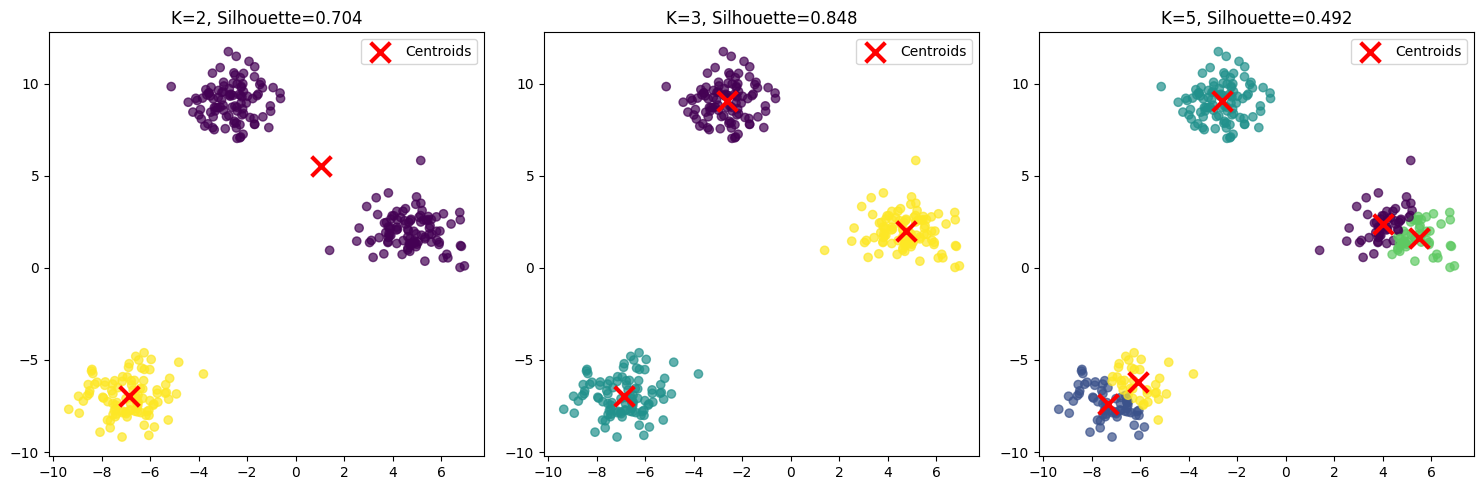

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

# Load the data - skip header row with Feature1, Feature2 labels
df = pd.read_csv('kmeans_wrongk.csv', header=0, skiprows=[0], names=['Feature1', 'Feature2'])

# Prepare features
X = df[['Feature1', 'Feature2']].values

# Function to apply KMeans and plot
def apply_kmeans(k, X):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    return kmeans, labels, score

# Apply for different K
results = {}
for k in [2, 3, 5]:
    kmeans, labels, score = apply_kmeans(k, X)
    results[k] = {'model': kmeans, 'labels': labels, 'silhouette': score}

# Plot each clustering
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, k in enumerate([2, 3, 5]):
    ax = axes[i]
    labels = results[k]['labels']
    score = results[k]['silhouette']
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
    ax.scatter(results[k]['model'].cluster_centers_[:, 0], 
               results[k]['model'].cluster_centers_[:, 1], 
               c='red', marker='x', s=200, linewidths=3, label='Centroids')
    ax.set_title(f'K={k}, Silhouette={score:.3f}')
    ax.legend()
plt.tight_layout()
plt.savefig('output/kmeans_comparison.png', dpi=300, bbox_inches='tight')

# Print silhouette scores
print("Silhouette Scores:")
for k in [2, 3, 5]:
    print(f"K={k}: {results[k]['silhouette']:.3f}")

In [ ]:
1.	What happens when K is too small? 
When K is too small in K-means clustering, the algorithm forces distinct groups of data into fewer clusters than naturally exist.
2.	What happens when K is too large?
When K is too large in K-means clustering, the algorithm splits natural clusters into too many smaller, artificial groups
3.	Which K best represents the data and why?
K=3 best represents your data. It aligns with the datasets natural structure of three distinct clusters visible in the Feature1-Feature2 scatter (bottom-left dense group, upper-right spread, and scattered outliers).